In [1]:
import nest
import numpy as np
import matplotlib.pyplot as plt


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: May 24 2024 10:10:57

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
n_total = 100
n_exc = 50
n_inh = 50
p_conn = 0.3
simtime = 1000.0

In [3]:
nest.ResetKernel()
nest.SetKernelStatus({"resolution": 0.1})

neuron_params = {
    "C_m": 250.0,
    "tau_m": 20.0,
    "t_ref": 2.0,
    "E_L": -70.0,
    "V_reset": -70.0,
    "V_th": -55.0,
}

exc_neurons = nest.Create("iaf_psc_alpha", n_exc, params=neuron_params)
inh_neurons = nest.Create("iaf_psc_alpha", n_inh, params=neuron_params)
all_neurons = exc_neurons + inh_neurons
ext_stim = nest.Create("poisson_generator", params={"rate": 8000.0})


Nov 23 17:41:07 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


In [4]:
conn_dict = {"rule": "pairwise_bernoulli", "p": p_conn}
J_exc, J_inh = 1.2, -1.8

# connect excitatory and inhibitory neurons
nest.Connect(exc_neurons, exc_neurons, conn_dict, syn_spec={"weight": J_exc})
nest.Connect(exc_neurons, inh_neurons, conn_dict, syn_spec={"weight": J_exc})
nest.Connect(inh_neurons, exc_neurons, conn_dict, syn_spec={"weight": J_inh})
nest.Connect(inh_neurons, inh_neurons, conn_dict, syn_spec={"weight": J_inh})
nest.Connect(ext_stim, all_neurons, syn_spec={"weight": 1.0})

In [5]:
mm = nest.Create("multimeter", params={"record_from": ["V_m"], "interval": 0.1})
nest.Connect(mm, all_neurons)

nest.Simulate(simtime)

events = nest.GetStatus(mm, "events")[0]
t = events["times"]
V = events["V_m"].reshape(len(all_neurons), -1)
print("Unperturbed voltage array shape:", V.shape)


Nov 23 18:03:31 NodeManager::prepare_nodes [Info]: 
    Preparing 102 nodes for simulation.

Nov 23 18:03:31 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 102
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Nov 23 18:03:31 SimulationManager::run [Info]: 
    Simulation finished.
Unperturbed voltage array shape: (100, 9990)


In [6]:
def extract_mm(mm):
    ev = nest.GetStatus(mm, "events")[0]
    senders, times, Vm = ev["senders"], ev["times"], ev["V_m"]
    ids = np.unique(senders)
    Vm_mat = np.vstack([Vm[senders == i] for i in ids])
    t_vec = times[senders == ids[0]]
    return Vm_mat, t_vec

def reset_state(neurons, v=-70.0):
    nest.SetStatus(neurons, {"V_m": v})

In [7]:
def run_perturbation(mode, mm, exc_neurons, inh_neurons, all_neurons, simtime,
                     idx=0, scale=2.0, subset=None, amp=500.0, rate=30000.0,
                     t_start=200.0, t_stop=800.0, pulse_steps=(200., 600., 900.), pulse_amps=(300., 0., 300.)):
    
    reset_state(all_neurons)
    nest.SetStatus(mm, {"n_events": 0})
    cleanup = []

    if mode == "knockout_dc":
        n = all_neurons[idx]
        gen = nest.Create("dc_generator", params={"amplitude": -amp})
        nest.Connect(gen, n)
        cleanup.append(("gen", gen, n))

    # remove all synapses of one neuron
    elif mode == "lesion_io":
        n = all_neurons[idx]
        conns_out = nest.GetConnections(source=n)
        conns_in = nest.GetConnections(target=n)
        stored_weights = {
            "out": np.array(nest.GetStatus(conns_out, "weight")),
            "in":  np.array(nest.GetStatus(conns_in, "weight"))
        }
        # zero the weights
        nest.SetStatus(conns_out, [{"weight": 0.0} for _ in stored_weights["out"]])
        nest.SetStatus(conns_in,  [{"weight": 0.0} for _ in stored_weights["in"]])
        cleanup.append(("restore_io", n, stored_weights))

    # scale all inhibitory weights by a factor
    elif mode == "scale_inh":
        conns = nest.GetConnections(inh_neurons, all_neurons)
        w0 = np.array(nest.GetStatus(conns, "weight"))
        nest.SetStatus(conns, [{"weight": w * scale} for w in w0])
        cleanup.append(("scale_inh", conns, w0))

    nest.Simulate(simtime)
    Vm_mat, t_vec = extract_mm(mm)

    for kind, n, wdict in cleanup:
        if kind == "scale_inh":
            nest.SetStatus(a, [{"weight": w} for w in b])
        elif kind == "gen":
            nest.Disconnect(a, b)
        elif kind == "restore_io":
            co = nest.GetConnections(source=n)
            ci = nest.GetConnections(target=n)
            nest.SetStatus(co, [{"weight": w} for w in wdict["out"]])
            nest.SetStatus(ci, [{"weight": w} for w in wdict["in"]])
            
    return Vm_mat, t_vec

In [8]:
# pert_list = []

# #Vm_k0, t_k0 = run_perturbation("knockout_dc", mm, exc_neurons, inh_neurons, all_neurons, simtime, idx=0, amp=500.0)
# #pert_list.append(Vm_k0)

# n_lesions = 100  
# for i in range(n_lesions):
#     Vm_les, t_les = run_perturbation(
#         "lesion_io",
#         mm,
#         exc_neurons,
#         inh_neurons,
#         all_neurons,
#         simtime,
#         idx=i
#     )
#     pert_list.append(Vm_les)

# #Vm_scale, t_scale = run_perturbation("scale_inh", mm, exc_neurons, inh_neurons, all_neurons, simtime, scale=3.0)
# #pert_list.append(Vm_scale)

# perturbations = np.stack(pert_list, axis=0)  # (perturbation, neuron, time)
# t_single = t_les  
# print("perturbations:", perturbations.shape)

In [8]:
perturbations = []

for idx, neuron in enumerate(all_neurons):

    nest.SetStatus(all_neurons, {"V_m": -70.0})

    # knockout by strong hyperpolarization
    blocker = nest.Create("dc_generator", params={"amplitude": -100.0})
    nest.Connect(blocker, neuron)  

    nest.SetStatus(mm, {"n_events": 0})
    nest.Simulate(simtime)

    ev_p = nest.GetStatus(mm, "events")[0]
    V_p = ev_p["V_m"].reshape(len(all_neurons), -1)
    perturbations.append(V_p)

    nest.SetStatus(blocker, {"amplitude": 0.0})

perturbations = np.array(perturbations)
print("Perturbation array shape:", perturbations.shape)


Nov 23 18:03:40 NodeManager::prepare_nodes [Info]: 
    Preparing 103 nodes for simulation.

Nov 23 18:03:40 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 103
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Nov 23 18:03:40 SimulationManager::run [Info]: 
    Simulation finished.

Nov 23 18:03:40 NodeManager::prepare_nodes [Info]: 
    Preparing 104 nodes for simulation.

Nov 23 18:03:40 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 104
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Nov 23 18:03:41 SimulationManager::run [Info]: 
    Simulation finished.

Nov 23 18:03:41 NodeManager::prepare_nodes [Info]: 
    Preparing 105 nodes for simulation.

Nov 23 18:03:41 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 105
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Nov 23 18:03:41 SimulationManager::run [Info]: 
    S

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


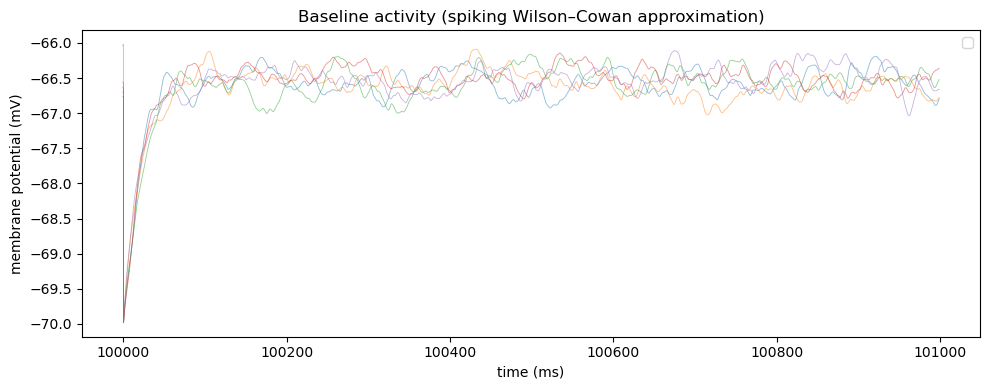

In [9]:
events = nest.GetStatus(mm, "events")[0]
senders = events["senders"]
times = events["times"]
Vm = events["V_m"]

unique_neurons = np.unique(senders)
n_neurons = len(unique_neurons)

Vm_mat = []
for n in unique_neurons:
    mask = senders == n
    Vm_mat.append(Vm[mask])
Vm_mat = np.array(Vm_mat)
t_single = times[senders == unique_neurons[0]]

plt.figure(figsize=(10, 4))
for i in range(min(5, n_neurons)):
    plt.plot(t_single, Vm_mat[i, :], lw=0.6, alpha=0.5)
plt.xlabel("time (ms)")
plt.ylabel("membrane potential (mV)")
plt.legend()
plt.title("Baseline activity (spiking Wilson–Cowan approximation)")
plt.tight_layout()
plt.show()

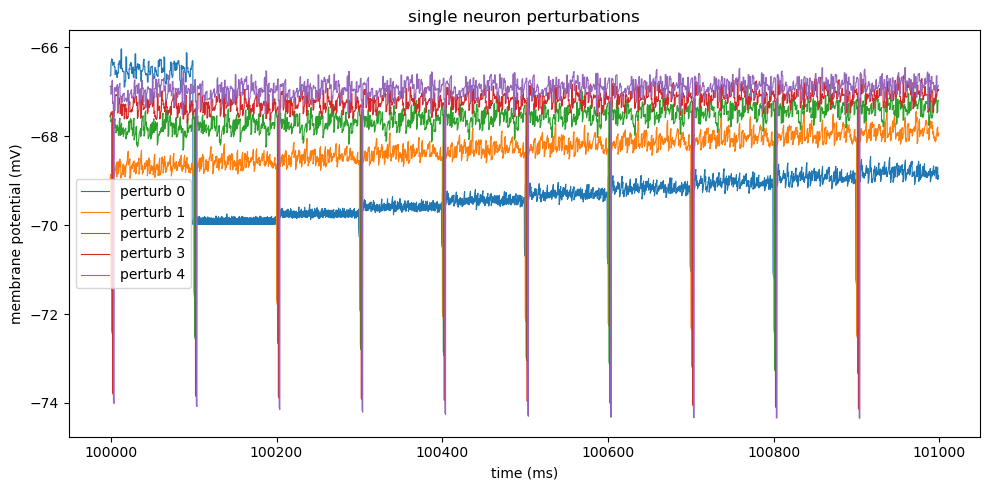

In [10]:
plt.figure(figsize=(10, 5))
for i in range(min(5, Vm_mat.shape[0])):
    plt.plot(t_single, perturbations[i, i, :len(t_single)], lw=0.8, label=f'perturb {i}')

plt.xlabel("time (ms)")
plt.ylabel("membrane potential (mV)")
plt.legend()
plt.title("single neuron perturbations")
plt.tight_layout()
plt.show()

In [11]:
out_file = "wc_spiking_activity.npy"
save_dict = {
    "time": t_single,
    "baseline": Vm_mat,             # shape: (neurons, time)
    "perturbations": perturbations  # shape: (perturbation, neuron, time)
}

np.savez_compressed(out_file, **save_dict)

print(f"Saved baseline + perturbation data → {out_file}")
print("baseline:", Vm_mat.shape, "perturbations:", perturbations.shape)

Saved baseline + perturbation data → wc_spiking_activity.npy
baseline: (100, 10000) perturbations: (100, 100, 10000)
